Here visuzilation of cosine similarity distribution is performed.

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from training.dataset_classes.lightning_datasets import MXFaceDataset
from training.models.scf import SoftmaxWeights
import onnx
from onnx import numpy_helper
from onnx2torch import convert
import tqdm
import gc

In [2]:
# ms1m_data = np.load("/app/cache/features/ms1m_emb.npz")
# labels = np.load("/app/datasets/ms1m/labels.npy")

In [3]:
# radius = 64
# features = torch.tensor(ms1m_data["embs"], dtype=torch.float32)
# softmax_weights = SoftmaxWeights(
#     softmax_weights_path="/app/model_weights/backbone/ms1mv3_arcface_r50/softmax_weight.pt",
#     radius=radius,
# ).softmax_weights
# wc = softmax_weights[labels, :]
# cosine_sim = torch.sum(features * wc, dim=1, keepdim=True) / radius
# cosine_sim = cosine_sim[:, 0].numpy()
# np.save("/app/model_weights/ms1m_cache/cosine_sim.npy", cosine_sim)

#### VGG face features

In [4]:
vgg_ds = MXFaceDataset("/app/datasets/faces_vgg_112x112")
vgg_loader = DataLoader(
    vgg_ds,
    batch_size=512,
    drop_last=False,
    shuffle=False,
    num_workers=40,
)
onnx_model = onnx.load("/app/model_weights/backbone/vgg_iresnet50/vgg2_r50.onnx")
vgg_model = convert(onnx_model)
vgg_model.eval()

vgg_model.to("cuda:0")

/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


GraphModule(
  (Conv_0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (initializers): Module()
  (PRelu_1): OnnxPReLU()
  (BatchNormalization_2): BatchNorm2d(64, eps=9.999999747378752e-06, momentum=0.10000002384185791, affine=True, track_running_stats=True)
  (Conv_3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (PRelu_4): OnnxPReLU()
  (Conv_5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (Conv_6): Conv2d(64, 64, kernel_size=(1, 1), stride=(2, 2))
  (Add_7): OnnxBinaryMathOperation()
  (BatchNormalization_8): BatchNorm2d(64, eps=9.999999747378752e-06, momentum=0.10000002384185791, affine=True, track_running_stats=True)
  (Conv_9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (PRelu_10): OnnxPReLU()
  (Conv_11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (Add_12): OnnxBinaryMathOperation()
  (BatchNormalization_13): BatchNorm2d(64, eps=9.999999747378752e-06, momentum=0.

In [5]:
sw_trained = torch.load(
    "/app/model_weights/backbone/vgg_iresnet50/softmax_weights_trained_correct.pt"
)
sw_trained = torch.nn.functional.normalize(sw_trained, p=2.0, dim=1)

/tmp/ipykernel_190944/3174723777.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sw_trained = torch.load("/app/model_weights/backbone/vgg_iresnet50/softmax_weights_train

In [6]:
s = 64
cosine = []
class_prob = []
for batch in tqdm.tqdm(vgg_loader):
    batch_cuda = batch[0].to("cuda:0")
    output = torch.nn.functional.normalize(vgg_model(batch_cuda), p=2.0, dim=1).detach()
    cos_current = torch.nn.functional.linear(output, sw_trained)
    cos_current = cos_current.cpu().numpy()
    train_labels = batch[1].cpu().numpy()
    p_z = np.exp(s * cos_current)
    true_class_prob = p_z[np.arange(p_z.shape[0]), train_labels] / np.sum(p_z, axis=1)
    class_prob.append(true_class_prob)
    cosine.append(cos_current[np.arange(batch[0].shape[0]), train_labels])

100%|██████████| 6129/6129 [25:28<00:00,  4.01it/s]


In [7]:
cosine = np.concatenate(cosine, axis=0)
class_prob = np.concatenate(class_prob, axis=0)
np.save("vgg2_cosine_arcface_new.npy", cosine)
np.save("vgg2_class_prob_arcface_new.npy", class_prob)

Text(0.5, 9.444444444444438, 'Class prob')

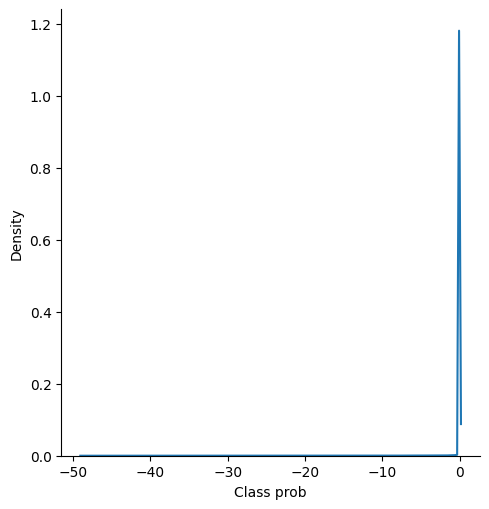

In [18]:
sns.displot(
    class_prob[],
    kind="kde",
    #x="Class prob",
    # hue="Error Kind",
    log_scale=False,
    common_norm=False,
)
plt.xlabel(f"Class prob")

In [23]:
eps = 10**-2
np.sum(class_prob > 1 - eps) / len(class_prob)

0.9893792065605055

In [16]:
class_prob

array([1.       , 1.       , 1.       , ..., 1.       , 0.9992214,
       1.       ], dtype=float32)

In [15]:
np.median(class_prob)

1.0

In [ ]:
1

Text(0.5, 9.444444444444438, 'Cosine Sim')

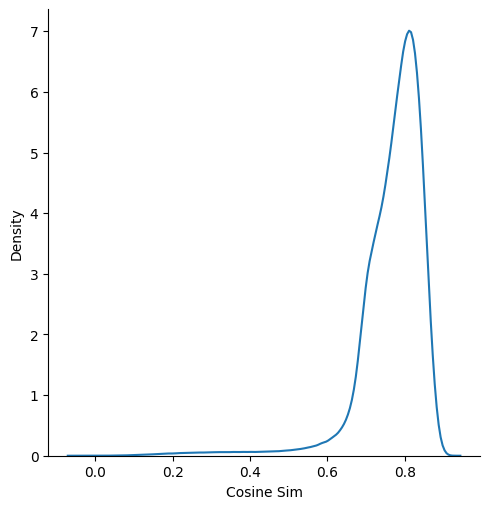

In [10]:
sns.displot(
    cosine,
    kind="kde",
    # x="Cosine Sim",
    # hue="Error Kind",
    log_scale=False,
    common_norm=False,
)
plt.xlabel(f"Cosine Sim")

In [9]:
cosine.shape, class_prob.shape

((3137807,), (3137807,))

### Uniform sampling

In [4]:
cosine_sim = np.load("/app/model_weights/ms1m_cache/cosine_sim.npy")
batch_size = 400
rng = np.random.default_rng(776)

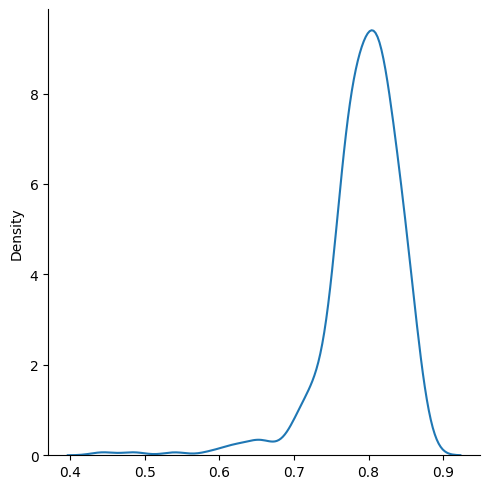

In [5]:
batch_ids = rng.choice(np.arange(cosine_sim.shape[0]), batch_size)
batch_cosine = cosine_sim[batch_ids]
sns.displot(
    batch_cosine,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

<AxesSubplot:ylabel='Count'>

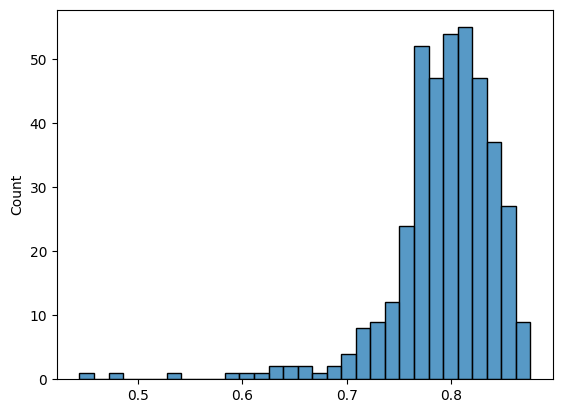

In [6]:
sns.histplot(
    batch_cosine,
    # kind="kde",
    log_scale=False,
    common_norm=False,
)

In [7]:
sorted_id_map = np.argsort(cosine_sim)

sorted_cosine_sim = np.sort(cosine_sim)
coarseness = 1
derivative_cosine_sim = np.gradient(
    sorted_cosine_sim[::coarseness], 1 / sorted_cosine_sim.shape[0]
)

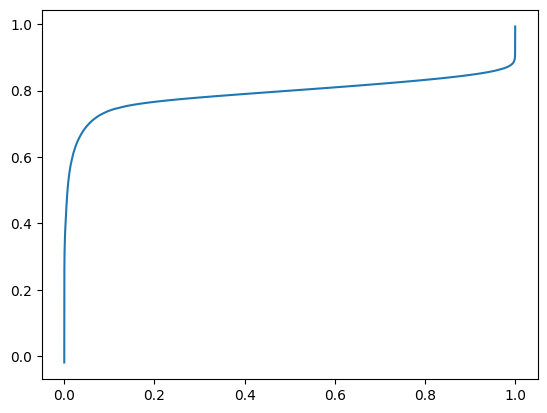

In [8]:
x_values = np.arange(sorted_cosine_sim.shape[0]) / sorted_cosine_sim.shape[0]
plt.plot(x_values, sorted_cosine_sim)
# plt.plot(x_values.numpy(), compute_function(x_values, params).detach().numpy())

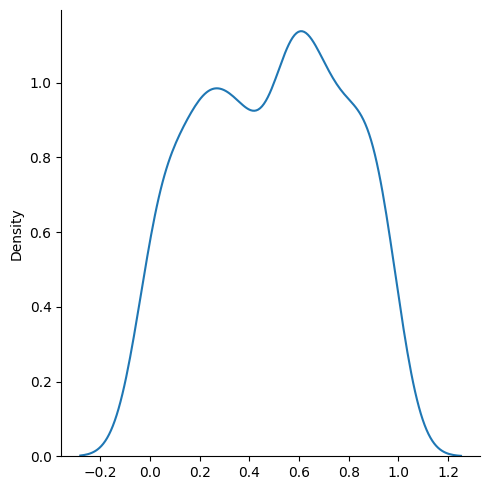

In [9]:
sorted_id_scores = np.array(
    [derivative_cosine_sim[i // coarseness] for i in range(len(sorted_id_map))]
)
sorted_batch_ids = rng.choice(
    np.arange(sorted_id_scores.shape[0]),
    batch_size,
    p=sorted_id_scores / np.sum(sorted_id_scores),
)
uniform_batch_ids = sorted_id_map[sorted_batch_ids]
uniform_batch_cosine = cosine_sim[uniform_batch_ids]
sns.displot(
    uniform_batch_cosine,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

<AxesSubplot:ylabel='Count'>

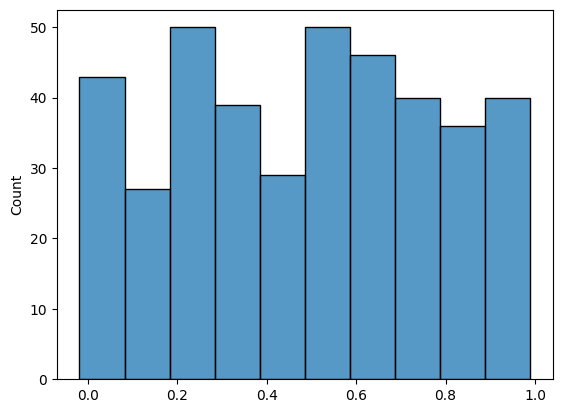

In [10]:
sns.histplot(
    uniform_batch_cosine,
    # kind="kde",
    log_scale=False,
    common_norm=False,
)

### Uniform binning

In [15]:
cosine_border_values = [0.7, 0.75, 0.8, 0.85, 1]
n_bins = len(cosine_border_values)
bin_sample_size = batch_size / n_bins
id_borders = []
id_widths = []
prev_border = 0
for cosine_border_values in cosine_border_values:
    id_border = np.searchsorted(sorted_cosine_sim, cosine_border_values)
    id_borders.append(id_border)
    id_widths.append(id_border - prev_border)
    prev_border = id_border
assert np.searchsorted(sorted_cosine_sim, 1) == sorted_cosine_sim.shape[0]

In [16]:
id_widths

[317920, 416375, 2188179, 2399689, 500490]

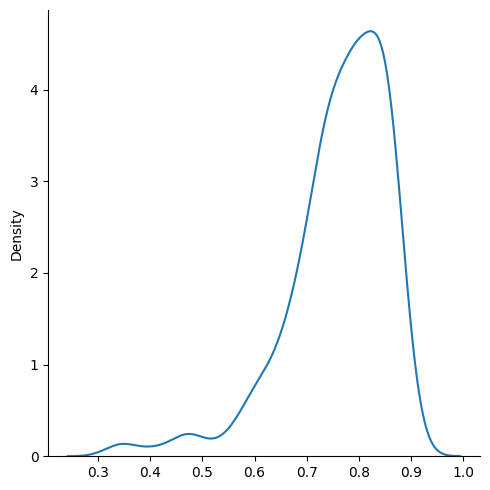

In [17]:
sorted_batch_ids = []
prev_id = 0
for id_border in id_borders:
    sorted_batch_ids.append(
        rng.choice(
            np.arange(prev_id, id_border),
            int(bin_sample_size),
        )
    )
    prev_id = id_border
sorted_batch_ids = np.concatenate(sorted_batch_ids)
uniform_batch_ids = sorted_id_map[sorted_batch_ids]
uniform_batch_cosine = cosine_sim[uniform_batch_ids]
sns.displot(
    uniform_batch_cosine,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

In [18]:
np.mean(uniform_batch_cosine)

0.7607561

<AxesSubplot:ylabel='Count'>

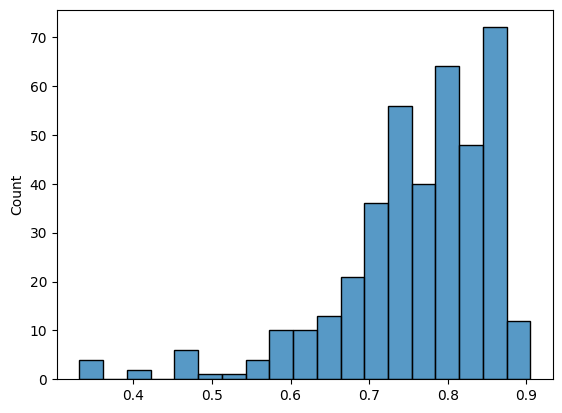

In [19]:
sns.histplot(
    uniform_batch_cosine,
    # kind="kde",
    log_scale=False,
    common_norm=False,
    # bins=[0, 0.5, 0.6, 0.7, 0.8, 1],
)

<AxesSubplot:ylabel='Count'>

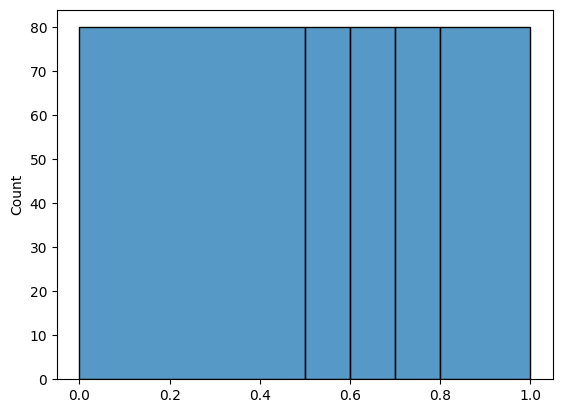

In [44]:
sns.histplot(
    uniform_batch_cosine,
    # kind="kde",
    log_scale=False,
    common_norm=False,
    bins=[0, 0.5, 0.6, 0.7, 0.8, 1],
)

Text(0.5, 9.444444444444438, 'Cosine Sim')

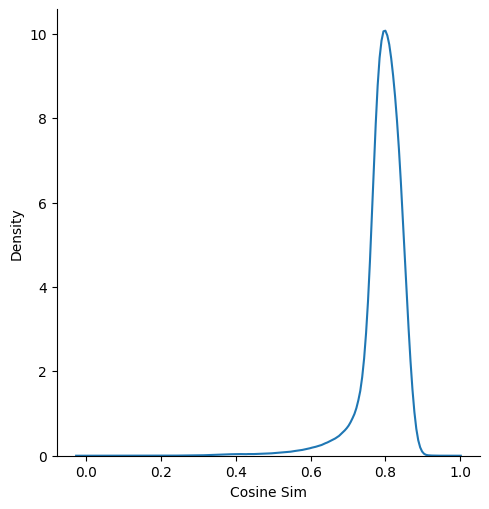

In [23]:
sns.displot(
    cosine_sim,
    kind="kde",
    # x="Cosine Sim",
    # hue="Error Kind",
    log_scale=False,
    common_norm=False,
)
plt.xlabel(f"Cosine Sim")
# plt.savefig(out_name, dpi=300)

/home/erlygin/miniconda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

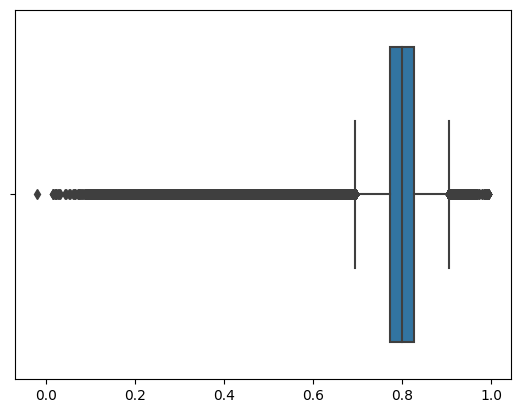

In [24]:
sns.boxplot(cosine_sim)

In [ ]:
### fit parametric curve
import torch

x_values = torch.tensor(
    np.arange(sorted_cosine_sim.shape[0]) / sorted_cosine_sim.shape[0],
    dtype=torch.float64,
)
sorted_cosine_sim_tensor = torch.tensor(sorted_cosine_sim, dtype=torch.float64)
params = {
    "a": torch.nn.Parameter(torch.tensor([1.0])),
    "b": torch.nn.Parameter(torch.tensor([1.0])),
    "c": torch.nn.Parameter(torch.tensor([1.0])),
    "d": torch.nn.Parameter(torch.tensor([1.0])),
}
optimizer = torch.optim.SGD(params=list(params.values()), lr=0.1)


def compute_function(x, params):
    return params["a"] * x**3 + params["b"] * x**2 + params["c"] * x + params["d"]


num_steps = 500
loss = torch.nn.MSELoss()
# for i in range(num_steps):
#     optimizer.zero_grad()
#     prediction = compute_function(x_values, params)
#     mse_loss = loss(prediction, sorted_cosine_sim_tensor)
#     mse_loss.backward()
#     optimizer.step()
#     print(f'iter: {i} loss: {mse_loss.item()}  ' + '_'.join([str(x.item()) for x in list(params.values())]))